In [1]:
import os
import dotenv
import sys
home = os.path.expanduser("~")

sys.path.append(os.path.expanduser("~/Rel3D"))

from dataloader import SpatialDataset

dotenv.load_dotenv()

if "DATA_PATH" not in os.environ:
    raise ValueError("DATA_PATH environment variable is not set.")

DATA_DIR = os.environ["DATA_PATH"]

# OUTPUT_DIR = os.path.join(DATA_DIR, "images/vsr") 
IMAGES_DIR = os.path.join(DATA_DIR, "images/Rel3D")
SAVE_DIR = os.path.join(DATA_DIR, "Rel3D")

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)

In [2]:
print(DATA_DIR)
print(IMAGES_DIR)
print(SAVE_DIR)

/scratch/izar/samaier/vlm_r1/data
/scratch/izar/samaier/vlm_r1/data/images/Rel3D
/scratch/izar/samaier/vlm_r1/data/Rel3D


### Generating the Rel3D dataset formatted to input it to GRPO training and to save it on disk

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import datasets
from tqdm import tqdm

In [4]:
# save to image to a jpg file
def save_image(image_tensor, filename):
    image = image_tensor.permute(1, 2, 0).numpy()
    plt.imsave(filename, image)


In [5]:
# take the number and add zeros in front of it to have a total of 6 digits
def add_zeros(num):
    return str(num).zfill(6)

In [13]:
splits = ["validation", "test", "train"]
dataset_split = {}
for split in splits:
    print(f"Processing {split} split...")

    os.makedirs(os.path.join(IMAGES_DIR, split), exist_ok=True)

    split_name = split if split != "validation" else "valid"

    _dataset_args = {
        "split": split_name,
        "predicate_dim": 30,
        "object_dim": 67,
        "data_path": '/home/samaier/Rel3D/data/c_0.9_c_0.1.json',
        "load_img": True,
        "data_aug_shift": False,
        "data_aug_color": False,
        "crop": False,
        "norm_data": False,
        "resize_mask": False,
        "trans_vec": [],
    }
    dataset = SpatialDataset(**_dataset_args)
    
    split_dataset = {'subject': [], 'predicate': [], 'object': [], 'label': [], 'image_path': []}
    for i, data in tqdm(enumerate(dataset)):
        subject = data['subject']['name']
        predicate = data['predicate']['name']
        object = data['object']['name']
        label = data['label']

        image_name = add_zeros(i) + ".jpg"

        image_path = os.path.join(IMAGES_DIR, split, image_name)

        save_image(data['img_crop'], image_path)

        split_dataset['subject'].append(subject)
        split_dataset['predicate'].append(predicate)
        split_dataset['object'].append(object)
        split_dataset['label'].append(label)
        split_dataset['image_path'].append(image_path)
        
    hf_dataset = datasets.Dataset.from_dict(split_dataset)
    dataset_split[split] = hf_dataset

dataset = datasets.DatasetDict(dataset_split)
dataset.save_to_disk(SAVE_DIR)


Processing validation split...
2138 relations in valid
Percentage of positive labels  in valid: 0.5
Percentage of negative labels  in valid: 0.5
{'in': (64, 64, 0.5), 'behind (wrt you)': (30, 30, 0.5), 'to the side of (wrt you)': (5, 5, 0.5), 'under': (71, 71, 0.5), 'to the left of': (11, 11, 0.5), 'points towards': (28, 28, 0.5), 'aligned to': (32, 32, 0.5), 'covering': (10, 10, 0.5), 'over': (56, 56, 0.5), 'on top of': (56, 56, 0.5), 'faces away': (40, 40, 0.5), 'to the left of (wrt you)': (50, 50, 0.5), 'around': (44, 44, 0.5), 'touching': (25, 25, 0.5), 'far from': (13, 13, 0.5), 'outside': (4, 4, 0.5), 'near': (24, 24, 0.5), 'to the right of': (17, 17, 0.5), 'leaning against': (33, 33, 0.5), 'to the right of (wrt you)': (53, 53, 0.5), 'faces towards': (39, 39, 0.5), 'in front of': (42, 42, 0.5), 'below': (50, 50, 0.5), 'passing through': (6, 6, 0.5), 'behind': (41, 41, 0.5), 'inside': (26, 26, 0.5), 'points away': (27, 27, 0.5), 'on': (93, 93, 0.5), 'to the side of': (50, 50, 0.5)

2138it [00:17, 123.92it/s]


Processing test split...
4744 relations in test
Percentage of positive labels  in test: 0.5
Percentage of negative labels  in test: 0.5
{'in': (145, 145, 0.5), 'behind (wrt you)': (64, 64, 0.5), 'to the side of (wrt you)': (36, 36, 0.5), 'under': (47, 47, 0.5), 'to the left of': (30, 30, 0.5), 'points towards': (69, 69, 0.5), 'aligned to': (58, 58, 0.5), 'covering': (157, 157, 0.5), 'over': (218, 218, 0.5), 'on top of': (74, 74, 0.5), 'faces away': (77, 77, 0.5), 'to the left of (wrt you)': (126, 126, 0.5), 'around': (82, 82, 0.5), 'touching': (66, 66, 0.5), 'to the right of': (60, 60, 0.5), 'far from': (47, 47, 0.5), 'near': (119, 119, 0.5), 'outside': (12, 12, 0.5), 'leaning against': (37, 37, 0.5), 'to the right of (wrt you)': (115, 115, 0.5), 'faces towards': (60, 60, 0.5), 'in front of': (64, 64, 0.5), 'below': (74, 74, 0.5), 'passing through': (53, 53, 0.5), 'behind': (33, 33, 0.5), 'inside': (60, 60, 0.5), 'points away': (63, 63, 0.5), 'on': (116, 116, 0.5), 'to the side of': (1

4744it [00:37, 127.91it/s]


Processing train split...
20454 relations in train
Percentage of positive labels  in train: 0.5
Percentage of negative labels  in train: 0.5
{'in': (497, 497, 0.5), 'behind (wrt you)': (266, 266, 0.5), 'to the side of (wrt you)': (72, 72, 0.5), 'under': (751, 751, 0.5), 'to the left of': (154, 154, 0.5), 'points towards': (224, 224, 0.5), 'aligned to': (232, 232, 0.5), 'covering': (128, 128, 0.5), 'over': (557, 557, 0.5), 'on top of': (656, 656, 0.5), 'faces away': (495, 495, 0.5), 'to the left of (wrt you)': (509, 509, 0.5), 'around': (326, 326, 0.5), 'touching': (276, 276, 0.5), 'far from': (89, 89, 0.5), 'outside': (28, 28, 0.5), 'near': (225, 225, 0.5), 'to the right of': (161, 161, 0.5), 'leaning against': (330, 330, 0.5), 'to the right of (wrt you)': (477, 477, 0.5), 'faces towards': (454, 454, 0.5), 'in front of': (410, 410, 0.5), 'below': (466, 466, 0.5), 'passing through': (72, 72, 0.5), 'behind': (427, 427, 0.5), 'inside': (213, 213, 0.5), 'points away': (284, 284, 0.5), 'on'

20454it [02:39, 128.23it/s]


Saving the dataset (0/1 shards):   0%|          | 0/2138 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4744 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/20454 [00:00<?, ? examples/s]

In [14]:
import random

In [15]:
dataset = datasets.load_from_disk(SAVE_DIR)["train"]
random_indices = random.sample(range(len(dataset)), 10)
dataset = dataset.select(random_indices)
print(len(dataset))

10


In [16]:
print(dataset[0])

{'subject': 'Airplane', 'predicate': 'near', 'object': 'Fruit', 'label': False, 'image_path': '/scratch/izar/samaier/vlm_r1/data/images/Rel3D/train/009147.jpg'}


In [17]:
dataset = dataset.map(lambda sample: {
        "problem": f'Is the following statement true: {sample["subject"]} {sample["predicate"]} {sample["object"]}?',
        "solution": sample["label"],
    }, remove_columns=["label", "predicate", "subject", "object"], desc="Preprocessing dataset")
print(dataset[0])

Preprocessing dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

{'image_path': '/scratch/izar/samaier/vlm_r1/data/images/Rel3D/train/009147.jpg', 'problem': 'Is the following statement true: Airplane near Fruit?', 'solution': False}


In [ ]:
_dataset_args = {
    "split": 'train',
    "predicate_dim": 30,
    "object_dim": 67,
    "data_path": '/home/samaier/Rel3D/data/c_0.9_c_0.1.json',
    "load_img": True,
    "data_aug_shift": False,
    "data_aug_color": False,
    "crop": False,
    "norm_data": False,
    "resize_mask": False,
    "trans_vec": [],
}

dataset = SpatialDataset(**_dataset_args)

20454 relations in train
Percentage of positive labels  in train: 0.5
Percentage of negative labels  in train: 0.5
{'in': (497, 497, 0.5), 'inside': (213, 213, 0.5), 'to the side of (wrt you)': (72, 72, 0.5), 'points away': (284, 284, 0.5), 'on': (722, 722, 0.5), 'far from': (89, 89, 0.5), 'points towards': (224, 224, 0.5), 'behind': (427, 427, 0.5), 'below': (466, 466, 0.5), 'to the right of (wrt you)': (477, 477, 0.5), 'on top of': (656, 656, 0.5), 'outside': (28, 28, 0.5), 'aligned to': (232, 232, 0.5), 'faces towards': (454, 454, 0.5), 'passing through': (72, 72, 0.5), 'faces away': (495, 495, 0.5), 'behind (wrt you)': (266, 266, 0.5), 'leaning against': (330, 330, 0.5), 'near': (225, 225, 0.5), 'over': (557, 557, 0.5), 'in front of': (410, 410, 0.5), 'to the left of': (154, 154, 0.5), 'around': (326, 326, 0.5), 'touching': (276, 276, 0.5), 'under': (751, 751, 0.5), 'to the right of': (161, 161, 0.5), 'to the side of': (515, 515, 0.5), 'covering': (128, 128, 0.5), 'to the left of (

In [75]:
print(len(dataset))

20454


In [65]:
dataset[0]

{'subject': {'name': 'Block',
  'idx': 41,
  'bbox': array([0.51339287, 0.625     , 0.28125   , 0.3169643 ], dtype=float32),
  't': array([ 0.5772727, -0.0433526, -1.0369186, -2.1328664], dtype=float32)},
 'object': {'name': 'Desk ',
  'idx': 3,
  'bbox': array([0.3392857 , 0.6473214 , 0.29464287, 0.56696427], dtype=float32),
  't': array([-1.628205  ,  0.36585358,  1.0369186 ,  2.1328664 ], dtype=float32)},
 'predicate': {'name': 'aligned to',
  'idx': 19,
  'bbox': array([0.3392857 , 0.6473214 , 0.28125   , 0.56696427], dtype=float32)},
 'label': True,
 'rgb_source': './data/20200223/aligned to - Block_036_wood_block - Desk _efe2bb181502eac1f3c9c1464e55d580 - initialState cam3 rgb.png',
 'weight': 0.8076804083948199,
 'img_crop': tensor([[[0.6784, 0.7490, 0.7529,  ..., 0.7569, 0.7569, 0.6941],
          [0.7294, 0.8039, 0.8118,  ..., 0.8157, 0.8157, 0.7412],
          [0.7333, 0.8039, 0.8039,  ..., 0.8157, 0.8118, 0.7373],
          ...,
          [0.3647, 0.4000, 0.4000,  ..., 0.400

In [66]:
print(dataset[0]['bbox_mask'].shape)

torch.Size([2, 224, 224])


In [67]:
from einops import repeat
import torch

Image shape: torch.Size([3, 224, 224])
Depth shape: torch.Size([1, 224, 224])
Mask shape: torch.Size([2, 224, 224])


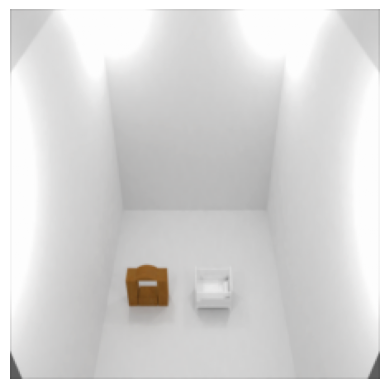

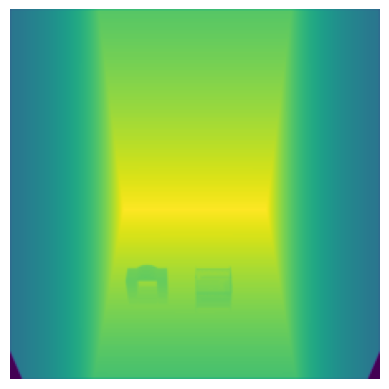

Child Bed aligned to Media Storage is True


In [68]:
# from a tensor of an image, show the image
import matplotlib.pyplot as plt
import numpy as np
def show_image(image_tensor):
    image = image_tensor.permute(1, 2, 0).numpy()
    plt.imshow(image)
    plt.axis('off')
    plt.show()
i = 10
datapoint = dataset[i]
print(f"Image shape: {datapoint['img_crop'].shape}")
print(f"Depth shape: {datapoint['depth_crop'].shape}")
print(f"Mask shape: {datapoint['bbox_mask'].shape}")
# show_image(datapoint['img_crop'] * repeat(datapoint['bbox_mask'][1].unsqueeze(0), 'b h w -> (repeat b) h w', repeat=3))
show_image(datapoint['img_crop'])
show_image(datapoint['depth_crop'])
print(f"{datapoint['subject']['name']} {datapoint['predicate']['name']} {datapoint['object']['name']} is {datapoint['label']}")

In [5]:
# save to image to a jpg file
def save_image(image_tensor, filename):
    image = image_tensor.permute(1, 2, 0).numpy()
    plt.imsave(filename, image)
save_image(dataset[0]['img_crop'], 'test.jpg')

In [ ]:
train_dataset = {'subject': [], 'predicate': [], 'object': [], 'label': []}